# Q1


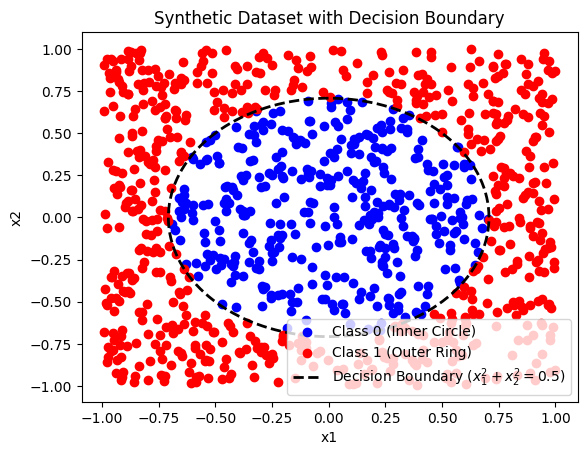

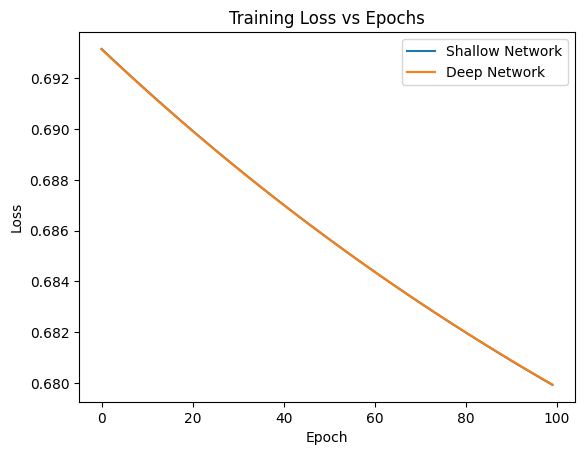

Shallow Network Accuracy: 0.585
Deep Network Accuracy: 0.585

Confusion Matrix (Shallow Network)
                Predicted 0   Predicted 1
Actual Class 0      0           83
Actual Class 1      0           117

Confusion Matrix (Deep Network)
                Predicted 0   Predicted 1
Actual Class 0      0           83
Actual Class 1      0           117


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# DATASET GENERATION
# -----------------------------

N = 1000

X = np.random.uniform(-1,1,(N,2))

y = ((X[:,0]**2 + X[:,1]**2) > 0.5).astype(int)
y = y.reshape(-1,1)

# train-test split
split = int(0.8*N)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]



plt.figure()

# class 0 points
scatter0 = plt.scatter(X[y[:,0]==0,0], X[y[:,0]==0,1],
                       color="blue", label="Class 0 (Inner Circle)")

# class 1 points
scatter1 = plt.scatter(X[y[:,0]==1,0], X[y[:,0]==1,1],
                       color="red", label="Class 1 (Outer Ring)")

# true decision boundary
theta = np.linspace(0, 2*np.pi, 300)
r = np.sqrt(0.5)

x_boundary = r*np.cos(theta)
y_boundary = r*np.sin(theta)

boundary_line, = plt.plot(x_boundary, y_boundary,
                          'k--', linewidth=2,
                          label=r"Decision Boundary ($x_1^2 + x_2^2 = 0.5$)")

plt.title("Synthetic Dataset with Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")

plt.legend()
plt.show()

# -----------------------------
# ACTIVATION FUNCTIONS
# -----------------------------

def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return (x>0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))


# -----------------------------
# LOSS FUNCTION
# -----------------------------

def binary_cross_entropy(y,yhat):
    eps = 1e-8
    return -np.mean(y*np.log(yhat+eps)+(1-y)*np.log(1-yhat+eps))


# -----------------------------
# MODEL INITIALIZATION
# -----------------------------

def init_weights(layer_sizes):

    weights = []
    biases = []

    for i in range(len(layer_sizes)-1):

        w = np.random.normal(0,0.01,(layer_sizes[i],layer_sizes[i+1]))
        b = np.zeros((1,layer_sizes[i+1]))

        weights.append(w)
        biases.append(b)

    return weights,biases


# -----------------------------
# FORWARD PASS
# -----------------------------

def forward(X,weights,biases):

    activations=[X]
    zs=[]

    a=X

    for i in range(len(weights)-1):

        z = a@weights[i] + biases[i]
        a = relu(z)

        zs.append(z)
        activations.append(a)

    # output layer

    z = a@weights[-1] + biases[-1]
    a = sigmoid(z)

    zs.append(z)
    activations.append(a)

    return activations,zs


# -----------------------------
# BACKPROPAGATION
# -----------------------------

def backward(y,weights,biases,activations,zs):

    grads_w=[]
    grads_b=[]

    m=y.shape[0]

    dz = activations[-1] - y

    for i in reversed(range(len(weights))):

        dw = activations[i].T @ dz / m
        db = np.mean(dz,axis=0,keepdims=True)

        grads_w.insert(0,dw)
        grads_b.insert(0,db)

        if i>0:
            da = dz @ weights[i].T
            dz = da * relu_derivative(zs[i-1])

    return grads_w,grads_b


# -----------------------------
# TRAINING FUNCTION
# -----------------------------

def train(X,y,layer_sizes,epochs=100,lr=0.01):

    weights,biases = init_weights(layer_sizes)

    losses=[]

    for epoch in range(epochs):

        activations,zs = forward(X,weights,biases)

        loss = binary_cross_entropy(y,activations[-1])
        losses.append(loss)

        grads_w,grads_b = backward(y,weights,biases,activations,zs)

        for i in range(len(weights)):
            weights[i] -= lr*grads_w[i]
            biases[i] -= lr*grads_b[i]

    return weights,biases,losses


# -----------------------------
# MODEL DEFINITIONS
# -----------------------------

# shallow network
model1 = [2,20,1]

# deep network
model2 = [2,10,10,1]


# -----------------------------
# TRAIN MODELS
# -----------------------------

w1,b1,loss1 = train(X_train,y_train,model1)
w2,b2,loss2 = train(X_train,y_train,model2)


# -----------------------------
# PLOT TRAINING LOSS
# -----------------------------

plt.plot(loss1,label="Shallow Network")
plt.plot(loss2,label="Deep Network")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss vs Epochs")
plt.show()


# -----------------------------
# PREDICTION FUNCTION
# -----------------------------

def predict(X,weights,biases):

    activations,_ = forward(X,weights,biases)
    probs = activations[-1]

    return (probs>0.5).astype(int)


# -----------------------------
# EVALUATION
# -----------------------------

def accuracy(y,yhat):
    return np.mean(y==yhat)


def confusion_matrix(y,yhat):

    tp = np.sum((y==1)&(yhat==1))
    tn = np.sum((y==0)&(yhat==0))
    fp = np.sum((y==0)&(yhat==1))
    fn = np.sum((y==1)&(yhat==0))

    return np.array([[tn,fp],[fn,tp]])


pred1 = predict(X_test,w1,b1)
pred2 = predict(X_test,w2,b2)


print("Shallow Network Accuracy:", accuracy(y_test,pred1))
print("Deep Network Accuracy:", accuracy(y_test,pred2))

cm1 = confusion_matrix(y_test,pred1)
cm2 = confusion_matrix(y_test,pred2)

print("\nConfusion Matrix (Shallow Network)")
print("                Predicted 0   Predicted 1")
print(f"Actual Class 0      {cm1[0,0]}           {cm1[0,1]}")
print(f"Actual Class 1      {cm1[1,0]}           {cm1[1,1]}")

print("\nConfusion Matrix (Deep Network)")
print("                Predicted 0   Predicted 1")
print(f"Actual Class 0      {cm2[0,0]}           {cm2[0,1]}")
print(f"Actual Class 1      {cm2[1,0]}           {cm2[1,1]}")


(e) Analysis

Representational Capacity

Representational capacity refers to the ability of a neural network to model complex decision boundaries. The shallow network contains one hidden layer with 20 neurons, which allows it to learn nonlinear transformations of the input. However, its ability to represent complex patterns is limited. The deeper network uses two hidden layers with 10 neurons each. Multiple layers allow the network to learn hierarchical feature representations, where earlier layers capture simple patterns and later layers combine them to form more complex features. As a result, deeper networks generally have higher representational capacity and can approximate more complex decision boundaries such as the circular boundary in this dataset.

Optimization Difficulty

Increasing network depth makes the optimization process more challenging. Deeper networks have more parameters and multiple nonlinear transformations, which can slow down training and make the optimization landscape more complex. Gradients must propagate through more layers during backpropagation, which can sometimes lead to slower convergence. In comparison, the shallow network is easier to optimize because it has fewer layers and a simpler parameter structure, so it often converges faster during training.

Generalization Performance

Generalization refers to how well the model performs on unseen test data. A deeper network typically has greater flexibility to capture the true underlying structure of the dataset. In this problem, the decision boundary is circular, which requires nonlinear modeling capability. Both models can approximate this boundary, but the deeper network may produce a smoother and more accurate boundary when trained properly. However, deeper networks also have a higher risk of overfitting if not trained carefully. With appropriate training settings, deeper networks often achieve slightly better generalization performance because of their higher expressive power.

# Q2

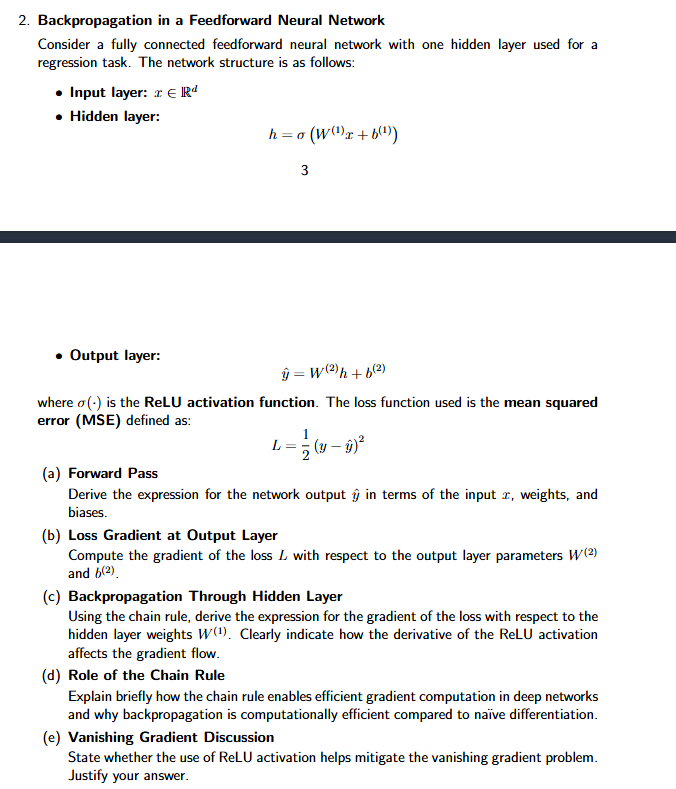

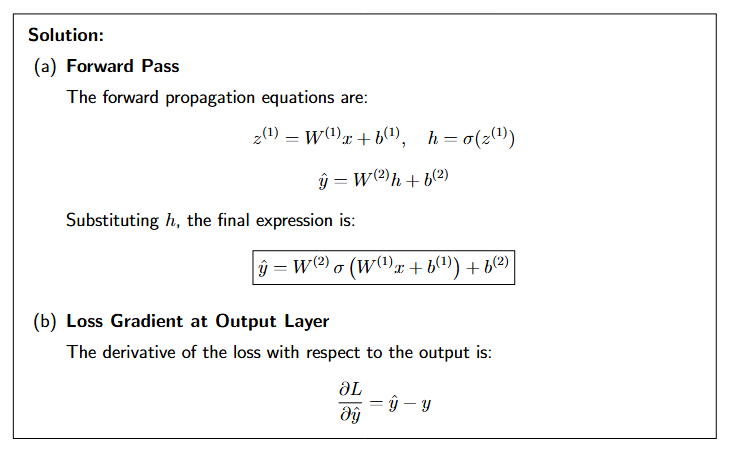

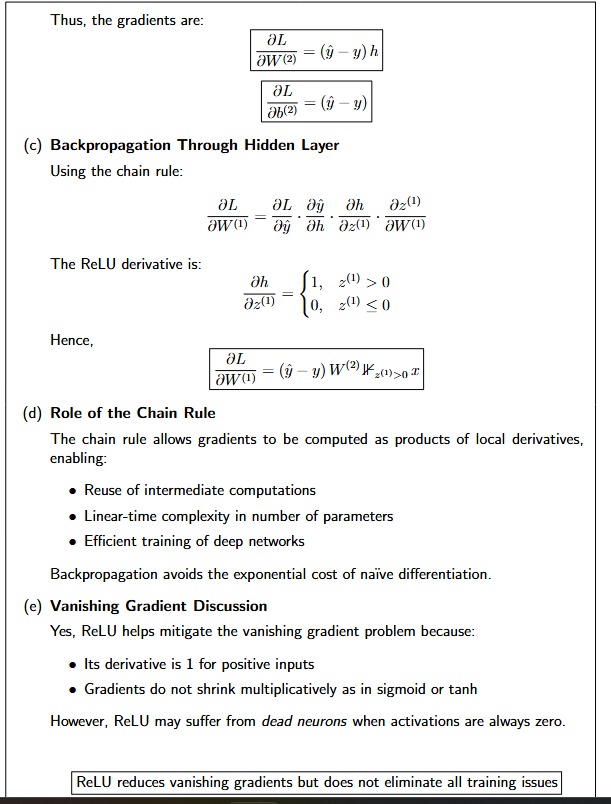

# Q3
**Simple Gradient Descent**

You are optimizing a loss function $\mathcal{L}(w) = w^4 - 10w^2 + 5w + 40$.

1. Start with an initial parameter $w_0 = 1$. Using a learning rate (step size) of $\eta = 0.01$, perform one manual iteration of gradient descent to find $w_1$. Calculate the squared error for $w_0$ and $w_1$. Did the loss decrease?
2. Will this setup of initial parameter $w_0 = 1$ reach global minima of the given error surface? Give the range of the initial parameter that will definitely converge to the global minima in the standard gradient descent approach.
3. If you chose a learning rate of $\eta = 2.0$ for this specific problem, what would happen to $w_1$ and the loss at $w_1$? Show the calculation.
4. Plot the loss function for the range $w \in [-3,3]$

# Answer

$\nabla L_{(w)} = 4w^3 - 20w + 5$

$w_{t+1} = w_t - \eta (\nabla L_{(w_t)})$

$w_{t+1} = 1 - 0.01 (-11) = 1.11$

Loss at w = 1 is 36 \
Loss at w = 1.11 is 34.74 \
Loss is decreasing

No the initial $w_0 = 1$ will not converge to the global minimum as the loss surface has a local and global minima.

Range that definitely converge $[- \infty,0.25]$

when ($\eta = 2.0$) \
$w_{t+1} = 1 - 2.0 (-11) = 23$ \
Loss at w = 23 is 274706. Loss increases \


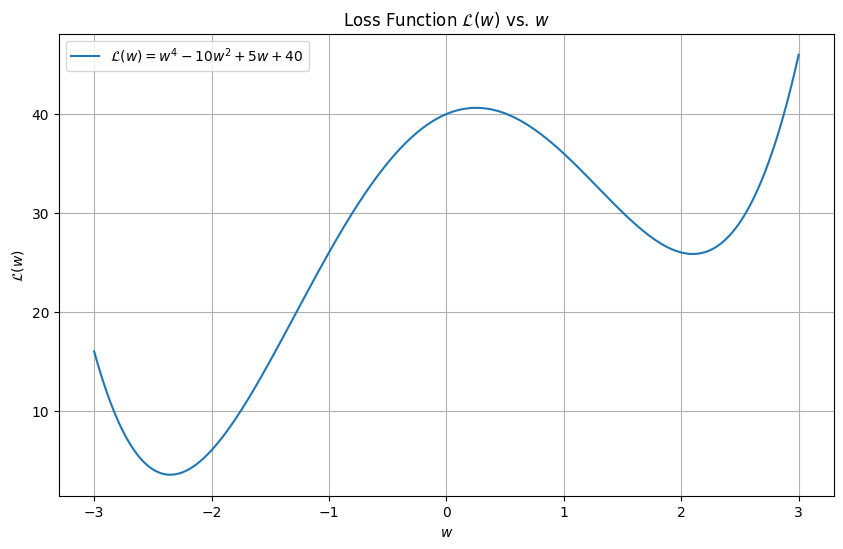

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Define the loss function
def loss_function(w):
    return w**4 - 10*w**2 + 5*w + 40

# Define the range for w
w_values = np.linspace(-3, 3, 500)  # 500 points between -3 and 3

# Calculate the corresponding loss values
loss_values = loss_function(w_values)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(w_values, loss_values, label='$\\mathcal{L}(w) = w^4 - 10w^2 + 5w + 40$')
plt.title('Loss Function $\\mathcal{L}(w)$ vs. $w$')
plt.xlabel('$w$')
plt.ylabel('$\\mathcal{L}(w)$')
plt.grid(True)
plt.legend()
plt.show()

# Q4

## Code the Activation Functions


- Create a class or set of functions in Python (using numpy) for the following activation functions: Sigmoid: $\sigma(x) = \frac{1}{1+e^{-x}}$ Tanh: $\tanh(x) = \frac{1-e^{-2x}}{1+e^{-2x}}$ ReLU: $\max(0, x)$ Leaky ReLU: $x$ if $x > 0$, else $\alpha x$ (use $\alpha=0.01$).
- Implement the derivative for each function.
- Visualization: Generate a range of inputs from -5 to 5. Plot each activation function and its corresponding derivative on the same graph.

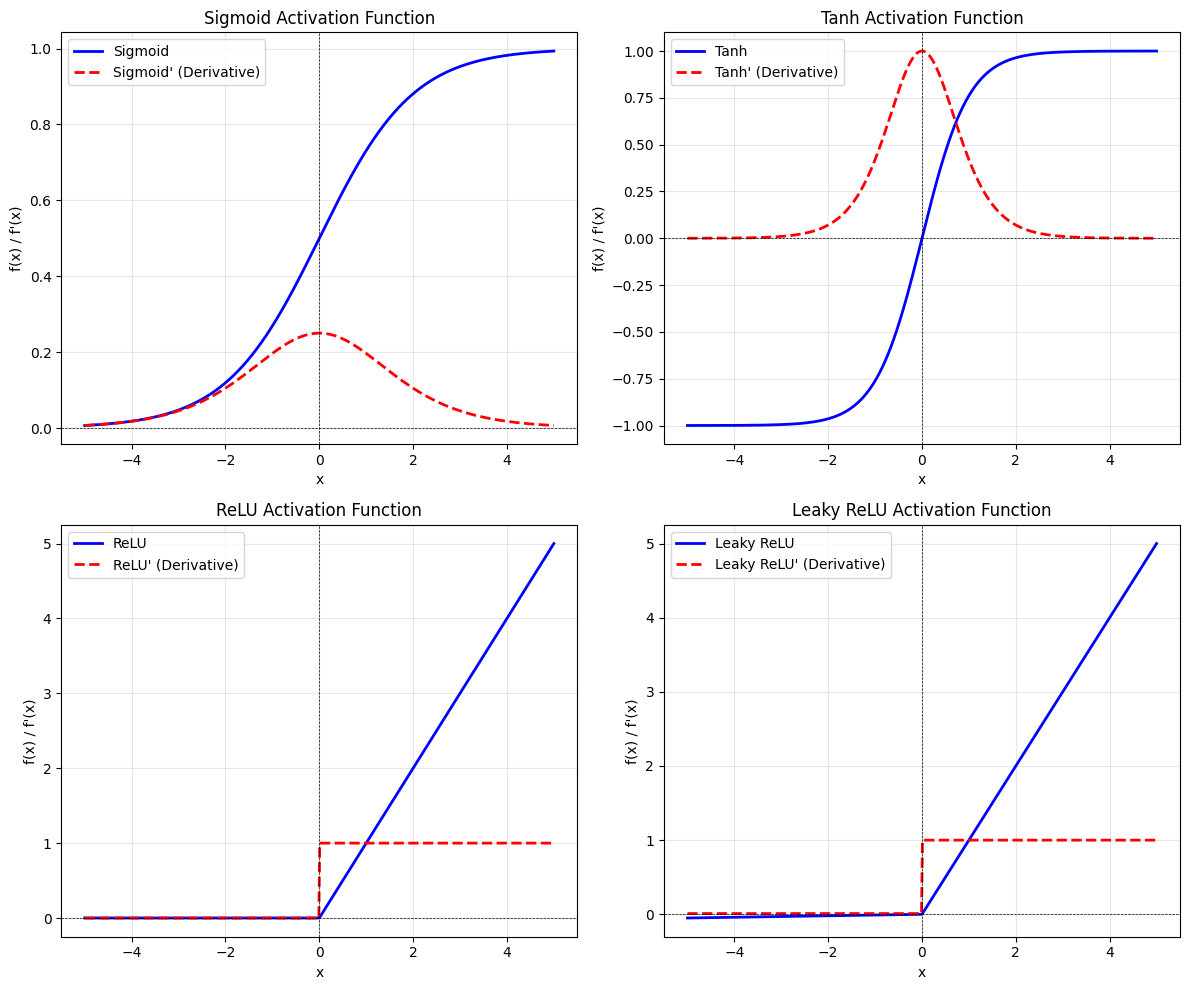

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class ActivationFunctions:
    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def sigmoid_derivative(x):
        s = ActivationFunctions.sigmoid(x)
        return s * (1 - s)

    @staticmethod
    def tanh(x):
        # Using the formulation provided (np.tanh(x) can also be used directly)
        return (1 - np.exp(-2 * x)) / (1 + np.exp(-2 * x))

    @staticmethod
    def tanh_derivative(x):
        t = ActivationFunctions.tanh(x)
        return 1 - t**2

    @staticmethod
    def relu(x):
        return np.maximum(0, x)

    @staticmethod
    def relu_derivative(x):
        # Returns 1 if x > 0, else 0
        return np.where(x > 0, 1.0, 0.0)

    @staticmethod
    def leaky_relu(x, alpha=0.01):
        # Returns x if x > 0, else alpha * x
        return np.where(x > 0, x, alpha * x)

    @staticmethod
    def leaky_relu_derivative(x, alpha=0.01):
        # Returns 1 if x > 0, else alpha
        return np.where(x > 0, 1.0, alpha)

def visualize_activations():
    # Generate a range of inputs from -5 to 5
    x = np.linspace(-5, 5, 500)

    # Map function names to their callable methods
    functions = {
        'Sigmoid': (ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
        'Tanh': (ActivationFunctions.tanh, ActivationFunctions.tanh_derivative),
        'ReLU': (ActivationFunctions.relu, ActivationFunctions.relu_derivative),
        'Leaky ReLU': (ActivationFunctions.leaky_relu, ActivationFunctions.leaky_relu_derivative)
    }

    # Set up a 2x2 grid for plotting
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()

    for i, (name, (func, deriv)) in enumerate(functions.items()):
        y = func(x)
        dy = deriv(x)

        # Plot function and its derivative on the same graph
        axs[i].plot(x, y, label=f'{name}', color='blue', linewidth=2)
        axs[i].plot(x, dy, label=f"{name}' (Derivative)", color='red', linestyle='--', linewidth=2)

        # Formatting
        axs[i].set_title(f'{name} Activation Function')
        axs[i].set_xlabel('x')
        axs[i].set_ylabel('f(x) / f\'(x)')
        axs[i].axhline(0, color='black', linewidth=0.5, linestyle='--')
        axs[i].axvline(0, color='black', linewidth=0.5, linestyle='--')
        axs[i].grid(True, alpha=0.3)
        axs[i].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_activations()

# Q6 Numerical Verification of Universal Approximation Theorem


### (a) Network Output Computation

Consider the target function:

$$
f(x) = \sin(2\pi x) + 0.5x^2, \quad x \in [0,1]
$$

The neural network output is:

$$
\hat{f}(x) = \sum_{i=1}^{3} \alpha_i \sigma(w_i x + b_i)
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The network parameters are:

$$
w = [2, -3, 4]
$$

$$
b = [-1, 2, -2]
$$

$$
\alpha = [1.5, -1, 0.5]
$$

---

### 1. For \( x = 0 \)

Hidden layer activations:

$$
z_1 = 2(0) - 1 = -1
$$

$$
z_2 = -3(0) + 2 = 2
$$

$$
z_3 = 4(0) - 2 = -2
$$

Applying sigmoid:

$$
\sigma(-1) = 0.2689
$$

$$
\sigma(2) = 0.8808
$$

$$
\sigma(-2) = 0.1192
$$

Network output:

$$
\hat{f}(0) = 1.5(0.2689) - 1(0.8808) + 0.5(0.1192)
$$

$$
\boxed{\hat{f}(0) \approx -0.4178}
$$

True function value:

$$\boxed{f(0) = 0}$$

---

### 2. For \( x = 0.5 \)

Hidden layer activations:

$$
z_1 = 2(0.5) - 1 = 0
$$

$$
z_2 = -3(0.5) + 2 = 0.5
$$

$$
z_3 = 4(0.5) - 2 = 0
$$

Applying sigmoid:

$$
\sigma(0) = 0.5
$$

$$
\sigma(0.5) = 0.6225
$$

Network output:

$$
\hat{f}(0.5) = 1.5(0.5) - 1(0.6225) + 0.5(0.5)
$$

$$
\boxed{\hat{f}(0.5) \approx 0.3775}
$$

True function value:

$$
\boxed{f(0.5) = \sin(\pi) + 0.5(0.25) = 0.125}
$$

---

### 3. For \( x = 1 \)

Hidden layer activations:

$$
z_1 = 2(1) - 1 = 1
$$

$$
z_2 = -3(1) + 2 = -1
$$

$$
z_3 = 4(1) - 2 = 2
$$

Applying sigmoid:

$$
\sigma(1) = 0.7311
$$

$$
\sigma(-1) = 0.2689
$$

$$
\sigma(2) = 0.8808
$$

Network output:

$$
\hat{f}(1) = 1.5(0.7311) - 1(0.2689) + 0.5(0.8808)
$$

$$
\boxed{\hat{f}(1) \approx 1.2682}
$$

True function value:

$$
\boxed{f(1) = \sin(2\pi) + 0.5 = 0.5}
$$

---

### (b) Mean Squared Error

$$
\text{MSE} = \frac{1}{3} \sum_{i=1}^{3} \left(f(x_i) - \hat{f}(x_i)\right)^2
$$

$$
= \frac{1}{3} \left[
(0 + 0.4178)^2 +
(0.125 - 0.3775)^2 +
(0.5 - 1.2682)^2
\right]
$$

$$
= \frac{1}{3} (0.1746 + 0.0638 + 0.5902)
$$

$$
\boxed{\text{MSE} \approx 0.2762}
$$

# Q7 Programming: Gradient Checking for Neural Network Training

In [ ]:
import numpy as np
np.random.seed(0)

# Activation functions
def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s*(1-s)

# Generate synthetic dataset
N = 20
X = np.random.uniform(-1,1,(N,2))
y = X[:,0]**2 + X[:,1]**2
y = y.reshape(-1,1)

# Initialize parameters
W1 = np.random.randn(5,2)*0.1
b1 = np.random.randn(5,1)*0.1

W2 = np.random.randn(1,5)*0.1
b2 = np.random.randn(1,1)*0.1

# Forward propagation
def forward(X):

    Z1 = W1 @ X.T + b1
    H = sigmoid(Z1)

    Z2 = W2 @ H + b2
    Yhat = Z2

    return Z1, H, Yhat

# Loss function
def loss(Yhat, y):
    return np.mean(0.5*(Yhat.T - y)**2)

# Backpropagation
def backprop(X,y,Z1,H,Yhat):

    N = X.shape[0]

    dZ2 = (Yhat.T - y)/N

    dW2 = dZ2.T @ H.T
    db2 = np.sum(dZ2)

    dH = dZ2 @ W2
    dZ1 = dH.T * sigmoid_grad(Z1)

    dW1 = dZ1 @ X
    db1 = np.sum(dZ1,axis=1,keepdims=True)

    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

# Gradient Checking
epsilon = 1e-5

def numerical_gradient(param, name):

    grad = np.zeros_like(param)

    it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])

    while not it.finished:
        idx = it.multi_index

        old_value = param[idx]

        param[idx] = old_value + epsilon
        _,_,y1 = forward(X)
        loss1 = loss(y1,y)

        param[idx] = old_value - epsilon
        _,_,y2 = forward(X)
        loss2 = loss(y2,y)

        grad[idx] = (loss1 - loss2)/(2*epsilon)

        param[idx] = old_value

        it.iternext()

    return grad

# Run forward pass
Z1,H,Yhat = forward(X)

# analytic gradients
grads = backprop(X,y,Z1,H,Yhat)

# numerical gradients
num_dW1 = numerical_gradient(W1,"W1")
num_db1 = numerical_gradient(b1,"b1")
num_dW2 = numerical_gradient(W2,"W2")
num_db2 = numerical_gradient(b2,"b2")

print("# numerical gradient")
print("\u001b[33mW1:\u001b[0m", num_dW1)
print("\u001b[33mb1:\u001b[0m", num_db1)
print("\u001b[33mW2:\u001b[0m", num_dW2)
print("\u001b[33mb2:\u001b[0m", num_db2)


# Compare gradients
def relative_error(a,b):
    return np.linalg.norm(a-b)/(np.linalg.norm(a)+np.linalg.norm(b)+1e-8)

print("\n# relative Error")
print("\u001b[33mW1 error:\u001b[0m", relative_error(grads["dW1"],num_dW1))
print("\u001b[33mb1 error:\u001b[0m", relative_error(grads["db1"],num_db1))
print("\u001b[33mW2 error:\u001b[0m", relative_error(grads["dW2"],num_dW2))
print("\u001b[33mb2 error:\u001b[0m", relative_error(grads["db2"],num_db2))

# numerical gradient
W1: [[ 0.00162824 -0.0052243 ]
 [-0.00318257  0.01102393]
 [-0.00042584  0.00147186]
 [-0.00182377  0.00617839]
 [ 0.0008108  -0.00263433]]
b1: [[-0.01490725]
 [ 0.03114634]
 [ 0.00413566]
 [ 0.01744913]
 [-0.00747314]]
W2: [[-0.34525042 -0.42976757 -0.38597558 -0.38023599 -0.35811074]]
b2: [[-0.78015695]]

# relative Error
W1 error: 1.7532235789369827e-10
b1 error: 7.682469866371075e-11
W2 error: 5.690771075730814e-12
b2 error: 4.32067372485978e-12


# Q8

Consider the problem of function approximation under different hypothesis
classes.

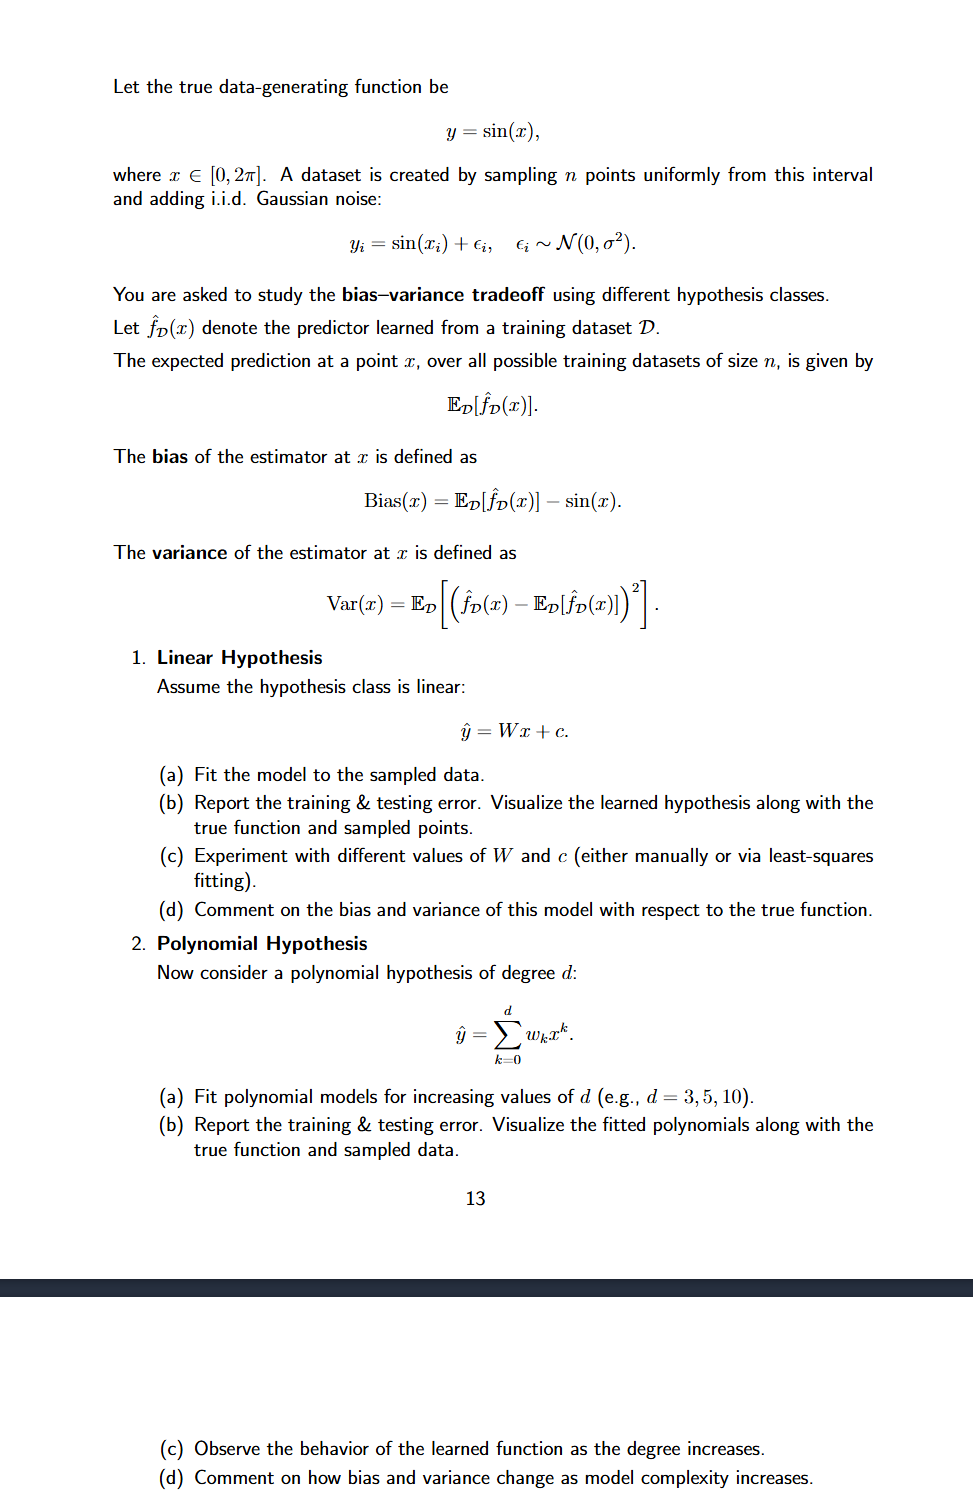

Linear Model Train MSE: 0.2407
Linear Model Test  MSE: 0.1948


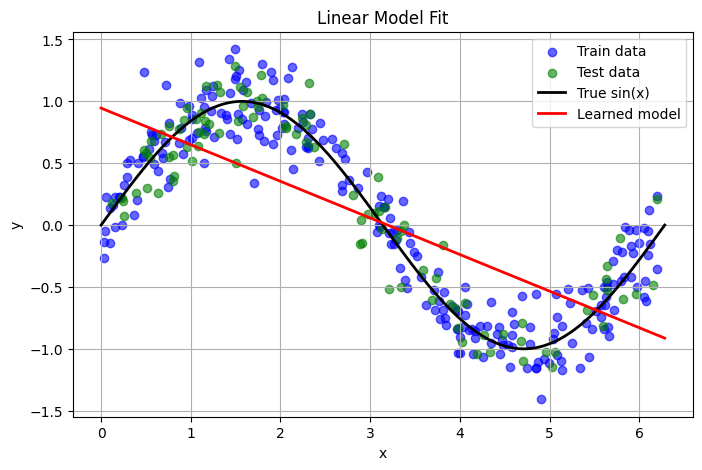

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Reproducibility
np.random.seed(42)

def generate_data(n, sigma=0.1):
    x = np.random.uniform(0, 2*np.pi, n)
    x = np.sort(x)
    y = np.sin(x) + np.random.normal(0, sigma, size=n)
    return x.reshape(-1, 1), y

def plot_model(x_train, y_train, x_test, y_test, x_grid, y_true, y_pred, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(x_train, y_train, color='blue', label='Train data', alpha=0.6)
    plt.scatter(x_test, y_test, color='green', label='Test data', alpha=0.6)
    plt.plot(x_grid, y_true, color='black', label='True sin(x)', linewidth=2)
    plt.plot(x_grid, y_pred, color='red', label='Learned model', linewidth=2)
    plt.legend()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

# Generate data
n_train = 250
n_test = 100
sigma = 0.2

x_train, y_train = generate_data(n_train, sigma)
x_test, y_test = generate_data(n_test, sigma)

# Linear model
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# Predictions
y_train_pred = linear_model.predict(x_train)
y_test_pred = linear_model.predict(x_test)

# Errors
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Linear Model Train MSE: {train_mse:.4f}")
print(f"Linear Model Test  MSE: {test_mse:.4f}")

# Plot
x_grid = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)
y_true = np.sin(x_grid)
y_grid_pred = linear_model.predict(x_grid)

plot_model(
    x_train, y_train,
    x_test, y_test,
    x_grid, y_true, y_grid_pred,
    "Linear Model Fit"
)


Polynomial Degree 3
Train MSE: 0.0427
Test  MSE: 0.0447


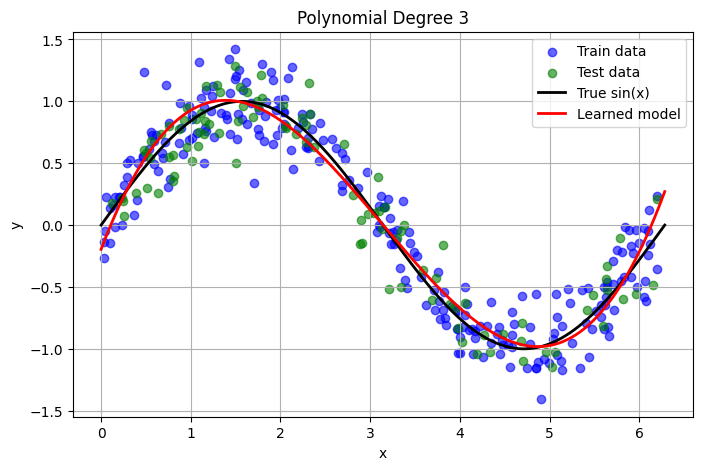


Polynomial Degree 10
Train MSE: 0.0380
Test  MSE: 0.0401


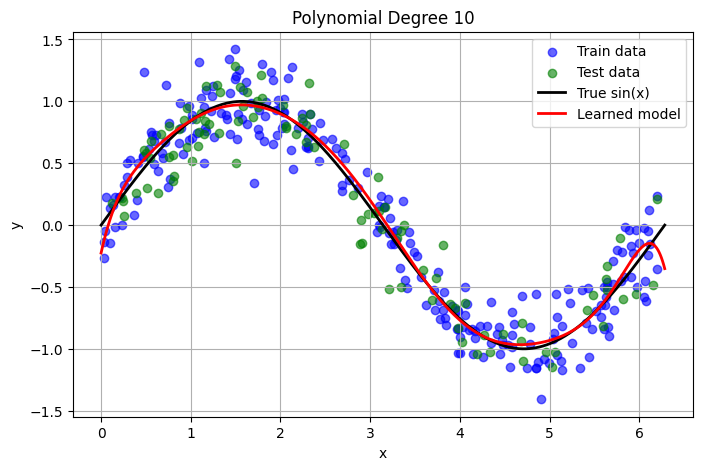


Polynomial Degree 25
Train MSE: 0.0761
Test  MSE: 0.0758


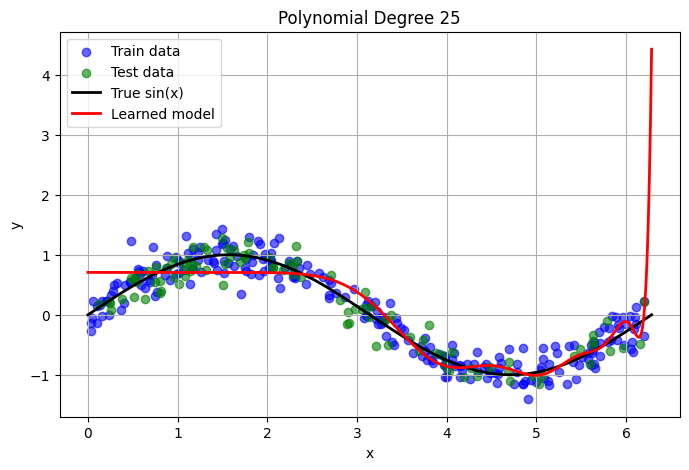

In [ ]:
def fit_polynomial_model(degree):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(x_train)
    X_test_poly = poly.transform(x_test)
    X_grid_poly = poly.transform(x_grid)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_grid_pred = model.predict(X_grid_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    return train_mse, test_mse, y_grid_pred



degrees = [3, 10, 25]

for d in degrees:
    train_mse, test_mse, y_grid_pred = fit_polynomial_model(d)

    print(f"\nPolynomial Degree {d}")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test  MSE: {test_mse:.4f}")

    plot_model(
        x_train, y_train,
        x_test, y_test,
        x_grid, y_true, y_grid_pred,
        f"Polynomial Degree {d}"
    )



# Q9
Consider a Multilayer Perceptron (MLP) consisting of fully connected layers with an activation function applied after each linear transformation.

1. Explain why activation functions are essential in an MLP. What would be the representational power of an MLP if no activation functions were used?

2. Discuss the role of nonlinearity in enabling MLPs to approximate complex functions. Briefly relate your answer to the Universal Approximation Theorem.

3. Compare sigmoid, tanh, and ReLU activation functions in terms of: output range, gradient behavior and suitability for deep networks.

4. 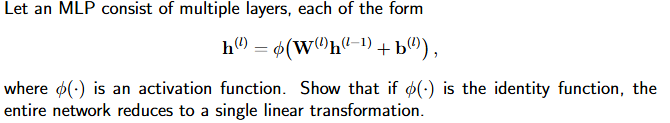

# Solution

1. Necessity of Activation Functions

Activation functions introduce nonlinearity into an MLP. Without activation functions,
each layer performs only an affine transformation. Composing multiple affine trans-
formations results in another affine transformation, regardless of the number of layers.
Consequently, an MLP without activation functions is equivalent to a single-layer linear
model and cannot represent nonlinear decision boundaries.

2. Role of Nonlinearity and Universal Approximation

Nonlinear activation functions allow MLPs to model complex, nonlinear relationships
between inputs and outputs. The Universal Approximation Theorem states that an MLP
with at least one hidden layer and a suitable nonlinear activation function can approximate
any continuous function on a compact set to arbitrary accuracy, given sufficient hidden
units. This expressive power is lost when activations are linear.

3. Comparison of Common Activation Functions

• Sigmoid: Outputs values in (0, 1). It suffers from vanishing gradients for large positive or negative inputs, making training deep networks difficult.

• Tanh: Outputs values in (−1, 1). It is zero-centered but still suffers from vanishing gradients in saturated regions.

• ReLU: Outputs max(0, x). It mitigates vanishing gradients for positive inputs
and enables faster training of deep networks, but may suffer from the dying ReLU
problem.

4. 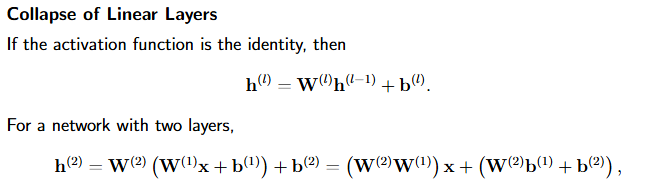

which is again a linear transformation. By induction, any number of such layers collapses
to a single linear mapping.

# 12. Basics of Computational Graphs

Consider the function

$$
z = (x + y)y
$$

where $x, y \in \mathbb{R}$.

---

# (a) Graph Representation

To construct the **computational graph**, we break the function into simple intermediate computations.

### Step 1: Define an intermediate variable

$$
a = x + y
$$

### Step 2: Compute the final output

$$
z = a \cdot y
$$

### Sequence of Computations

1. Inputs: $x, y$  
2. Addition node: $a = x + y$  
3. Multiplication node: $z = a \cdot y$

### Computational Graph

```
      x
       \
        (+) ---- a ---- (*) ---- z
       /                 /
      y                 /
                       /
                      y
```

Explanation:

- $x$ and $y$ are the **input nodes**
- The **addition node** computes $a = x + y$
- The **multiplication node** computes $z = a \cdot y$

---

# (b) Forward Evaluation

Given:

$$
x = 2, \quad y = 3
$$

### Step 1: Compute intermediate value

$$
a = x + y
$$

$$
a = 2 + 3 = 5
$$

### Step 2: Compute output

$$
z = a \cdot y
$$

$$
z = 5 \times 3 = 15
$$

### Final Result

$$
z = 15
$$

---

# (c) Gradient Computation

We compute gradients using **backpropagation and the chain rule**.

---

## Local Derivatives

From

$$
z = a \cdot y
$$

$$
\frac{\partial z}{\partial a} = y
$$

$$
\frac{\partial z}{\partial y} = a
$$

From

$$
a = x + y
$$

$$
\frac{\partial a}{\partial x} = 1
$$

$$
\frac{\partial a}{\partial y} = 1
$$

---

# Gradient with respect to $x$

Using the chain rule

$$
\frac{\partial z}{\partial x}
=
\frac{\partial z}{\partial a}
\cdot
\frac{\partial a}{\partial x}
$$

Substitute values

$$
\frac{\partial z}{\partial x} = y \cdot 1
$$

$$
\frac{\partial z}{\partial x} = y
$$

For $y = 3$

$$
\frac{\partial z}{\partial x} = 3
$$

---

# Gradient with respect to $y$

There are **two paths from $y$ to $z$**:

1. Direct path $y \rightarrow z$  
2. Through $a$: $y \rightarrow a \rightarrow z$

---

### Path 1

$$
\frac{\partial z}{\partial y} = a
$$

---

### Path 2

$$
\frac{\partial z}{\partial a} \cdot \frac{\partial a}{\partial y}
$$

$$
= y \cdot 1
$$

$$
= y
$$

---

### Total derivative

$$
\frac{\partial z}{\partial y} = a + y
$$

Substitute values

$$
a = 5, \quad y = 3
$$

$$
\frac{\partial z}{\partial y} = 5 + 3 = 8
$$

---

# Final Gradients

$$
\frac{\partial z}{\partial x} = 3
$$

$$
\frac{\partial z}{\partial y} = 8
$$

---

# (d) Conceptual Explanation

Computational graphs represent complex functions as a sequence of simple operations.  
This structure allows gradients to be computed efficiently using **backpropagation**, which is essential for training neural networks with gradient-based optimization algorithms.



## Q10

Consider a binary classification problem with input–label pairs

\[
x \in \mathbb{R}^d,\quad y \in \{0,1\}
\]

A fully connected neural network with input dimension **d** is trained using:

- Hidden Layer 1: size \( d/2 \)  
- Hidden Layer 2: size \( d/4 \)  
- Output Layer: single neuron  

All hidden layers use **sigmoid activation**.  
The output layer also uses **sigmoid activation**, and the loss function is **binary cross-entropy**.

The network is trained using gradient-based optimization under the following initialization settings:

1. All weights and biases are initialized to the **same constant value**
2. **Xavier initialization** is used for all layers
3. Weights are initialized randomly with **small independent noise**

---

# Solution

## General Principle

For a neural network to learn **meaningful representations**, neurons within the same layer must receive **different gradient updates**.

If neurons start with **identical parameters** and experience **identical gradients**, they remain identical throughout training. This prevents the network from learning diverse features.

Additionally, **stable gradient flow** is required to prevent **vanishing gradients**, especially in deeper networks.

---

# 1. Same Constant Initialization

All neurons within a layer are initialized with **identical weights and biases**.

As a result:

- Every neuron produces the **same activation** for a given input.
- During backpropagation, they receive **identical gradients**.
- Their parameters update in the **same way**.

This symmetry is preserved during training.

Since the hidden layers use **sigmoid activations**, gradients are non-zero but **identical across neurons**.

Therefore, each layer behaves like **a single neuron repeated multiple times**, drastically reducing the representational power of the network.

### Outcome

The network **fails to learn meaningful representations** and behaves similarly to a **shallow model with very limited capacity**.

---

# 2. Xavier Initialization

Xavier initialization assigns **independent random weights** with variance chosen to maintain **stable activation and gradient variance across layers**.

This provides two key benefits:

1. **Symmetry breaking**  
   Each neuron starts with different weights, so they produce different activations.

2. **Stable gradient flow**  
   The variance scaling prevents activations from becoming too large or too small, which helps avoid vanishing gradients.

As a result:

- Each neuron receives **different gradients**
- The network can learn **diverse features**
- Training becomes **more stable**

### Outcome

The network **learns meaningful hierarchical representations** and trains **efficiently and stably**.

---

# 3. Random Initialization with Small Noise

Random initialization with small independent noise **breaks symmetry**, allowing neurons to learn different features.

However, unlike Xavier initialization, the variance of the weights is **not carefully controlled**.

This can lead to:

- **Sigmoid saturation** (very large positive or negative inputs)
- **Vanishing gradients**

As the network depth increases, training may become **unstable or slow**.

### Outcome

The network **can learn**, but convergence may be **slower and less stable** compared to Xavier initialization.

---

# Conclusion

- **Constant initialization** fails due to symmetry preservation between neurons.
- **Xavier initialization** provides both **symmetry breaking and stable gradient flow**, enabling effective learning.
- **Random small initialization** breaks symmetry but may suffer from **unstable gradient propagation**.

Therefore, **Xavier initialization is the most reliable choice for sigmoid-based networks.**

Q11

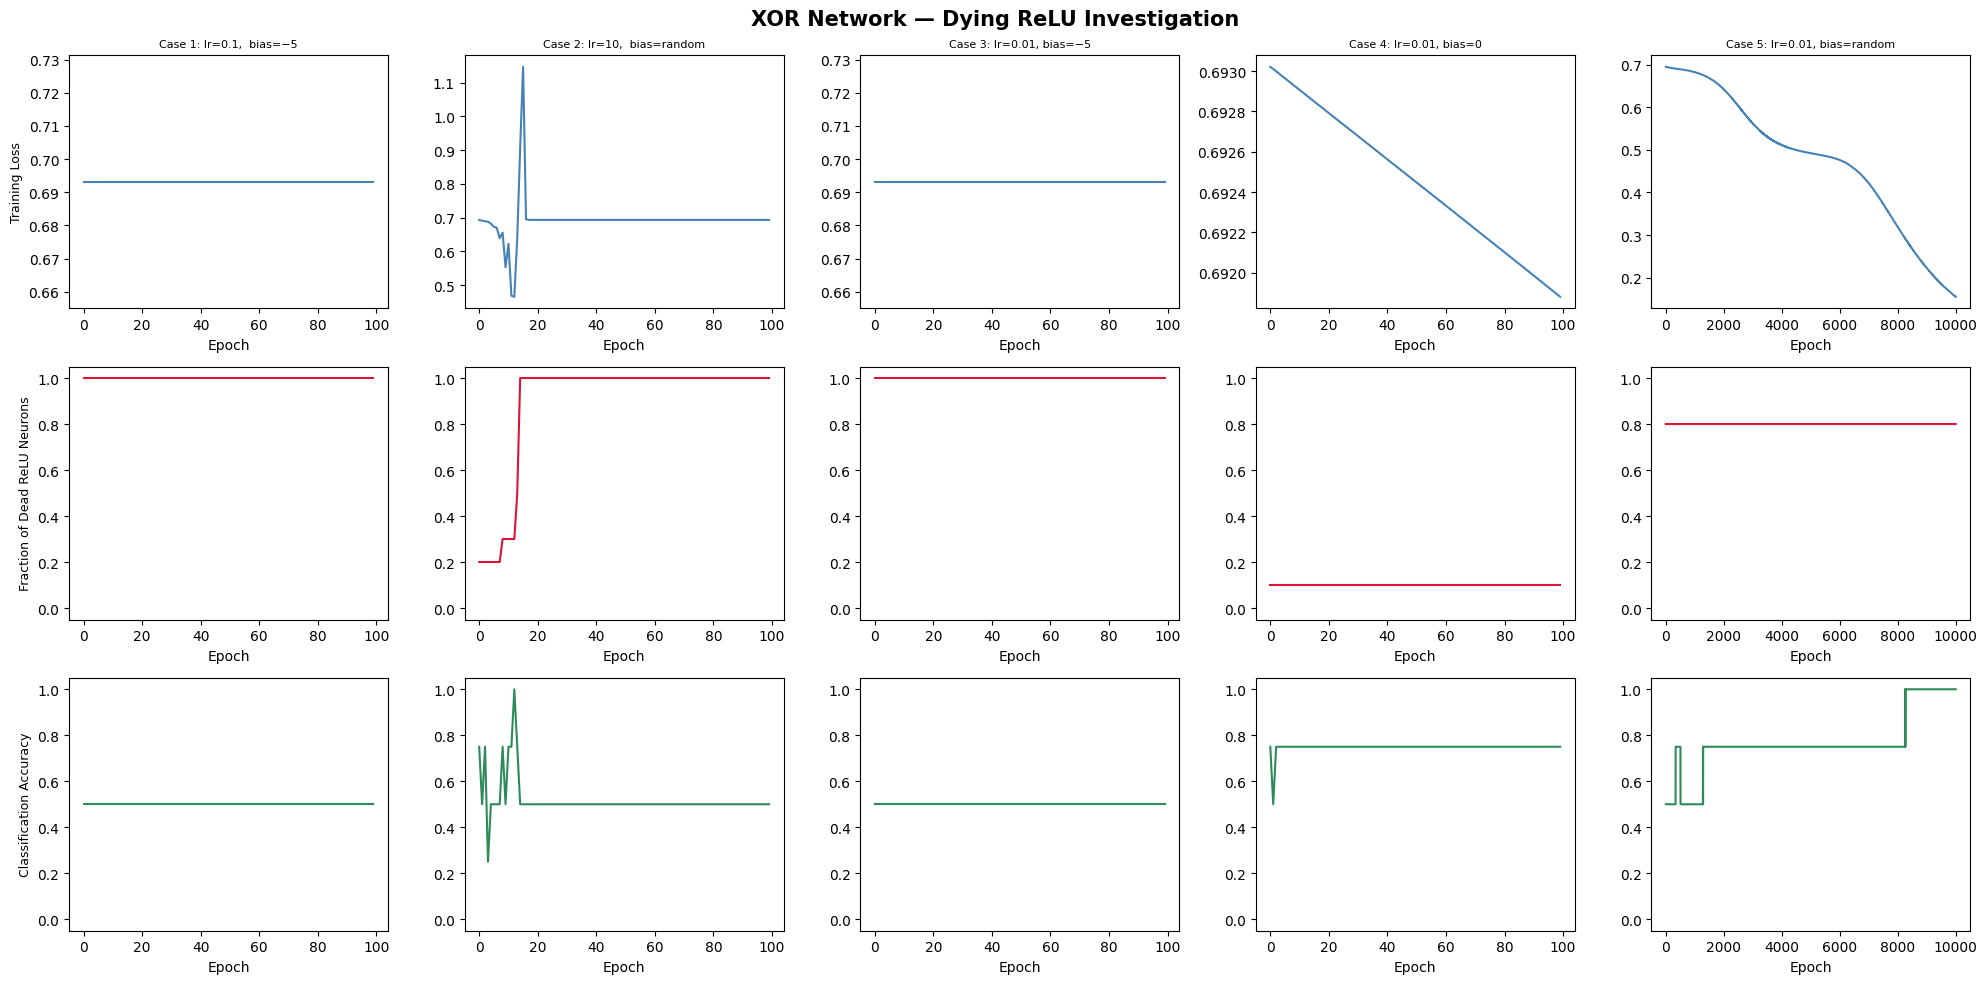

Saved.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ── XOR dataset ──────────────────────────────────────────────────────────────
X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]],         dtype=torch.float32)

# ── Network ───────────────────────────────────────────────────────────────────
class XORNet(nn.Module):
    def __init__(self, bias_init=0.0):
        super().__init__()
        self.hidden = nn.Linear(2, 10)
        self.output = nn.Linear(10, 1)

        # W ~ N(0, 0.01)
        nn.init.normal_(self.hidden.weight, mean=0, std=0.1)
        nn.init.normal_(self.output.weight, mean=0, std=0.1)

        # Bias initialization
        if bias_init == 'random':
            nn.init.uniform_(self.hidden.bias, -1, 1)
        else:
            nn.init.constant_(self.hidden.bias, bias_init)
        nn.init.constant_(self.output.bias, 0.0)

    def forward(self, x):
        self.hidden_out = torch.relu(self.hidden(x))   # save for dead-ReLU tracking
        return torch.sigmoid(self.output(self.hidden_out))

def count_dead_relu(model, x):
    with torch.no_grad():
        _ = model(x)
        # A neuron is "dead" if it outputs 0 for ALL training inputs
        dead = (model.hidden_out == 0).all(dim=0).sum().item()
    return dead / 10.0   # fraction

# ── Configurations ────────────────────────────────────────────────────────────
configs = [
    dict(lr=0.1,  bias=-5.0, epochs=100,   label='Case 1: lr=0.1,  bias=−5'),
    dict(lr=5,  bias=0,  epochs=100,   label='Case 2: lr=10,  bias=random'),
    dict(lr=0.01, bias=-5.0, epochs=100,   label='Case 3: lr=0.01, bias=−5'),
    dict(lr=0.01, bias=0.0,  epochs=100,   label='Case 4: lr=0.01, bias=0'),
    dict(lr=0.01, bias='random', epochs=10000, label='Case 5: lr=0.01, bias=random'),
]

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle('XOR Network — Dying ReLU Investigation', fontsize=15, fontweight='bold')

for col, cfg in enumerate(configs):
    torch.manual_seed(42)
    model = XORNet(bias_init=cfg['bias'])
    optimizer = optim.SGD(model.parameters(), lr=cfg['lr'])
    criterion = nn.BCELoss()

    losses, dead_fracs, accuracies = [], [], []

    for epoch in range(cfg['epochs']):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        dead_fracs.append(count_dead_relu(model, X))
        preds = (out.detach() > 0.5).float()
        acc = (preds == y).float().mean().item()
        accuracies.append(acc)

    ep = range(cfg['epochs'])

    # Row 0: Training loss
    axes[0, col].plot(ep, losses, color='steelblue')
    axes[0, col].set_title(cfg['label'], fontsize=8)
    axes[0, col].set_ylabel('Loss' if col == 0 else '')
    axes[0, col].set_xlabel('Epoch')

    # Row 1: Dead ReLU fraction
    axes[1, col].plot(ep, dead_fracs, color='crimson')
    axes[1, col].set_ylim(-0.05, 1.05)
    axes[1, col].set_ylabel('Fraction Dead' if col == 0 else '')
    axes[1, col].set_xlabel('Epoch')

    # Row 2: Accuracy
    axes[2, col].plot(ep, accuracies, color='seagreen')
    axes[2, col].set_ylim(-0.05, 1.05)
    axes[2, col].set_ylabel('Accuracy' if col == 0 else '')
    axes[2, col].set_xlabel('Epoch')

row_labels = ['Training Loss', 'Fraction of Dead ReLU Neurons', 'Classification Accuracy']
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.tight_layout()
plt.savefig('xor_dying_relu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")